KLASYFIKACJA BINARNA - Breast Cancer

Rozmiar danych: (569, 30)
Liczba klas: 2


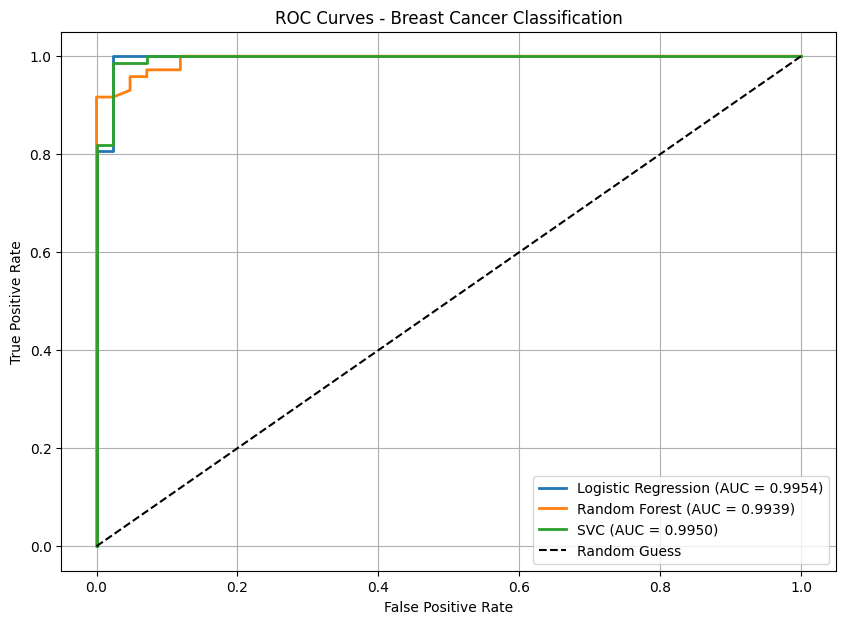

In [ ]:
# Porównaj 3 modele klasyfikacji binarnej za pomocą ROC curves.
# Dataset: Breast Cancer
# Wymagania:
# Logistic Regression, Random Forest, SVM
# Wykres ROC curves na jednym wykresie
# Wydrukuj AUC dla każdego modelu

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score

# Generowanie danych
data = load_breast_cancer()
X = data.data
y = data.target

print("KLASYFIKACJA BINARNA - Breast Cancer")

print(f"\nRozmiar danych: {X.shape}")
print(f"Liczba klas: {len(np.unique(y))}")

# Podział i preprocessing
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)
# Skalowanie
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Trening trzech modeli
models = {
'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42), # Próbuje obliczyć :P(y=1)
'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42), # To las drzew decyzyjnych.Każde drzewo podejmuje decyzję osobno.
'SVC': SVC(kernel='rbf', probability=True,random_state=42) # SVM szuka najlepszej granicy między klasami.
}
# Trening + ROC/AUC
plt.figure(figsize=(10, 7))
results = {}
for name, model in models.items():
# trening
    model.fit(X_train_scaled, y_train) # analizuje dane treningowe,

# prawdopodobieństwa klasy pozytywnej
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# AUC
auc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob) # ROC curve pokazuje jak dobrze model odróżnia klasy.

results[name] = auc

# wykres
plt.plot(fpr, tpr, linewidth=2,
             label=f"{name} (AUC = {auc:.4f})")

# linia losowego klasyfikatora
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title("ROC Curves - Breast Cancer Classification")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

Rozmiar zbioru treningowego: 1257
Rozmiar zbioru testowego: 540


NameError: name 'ax' is not defined

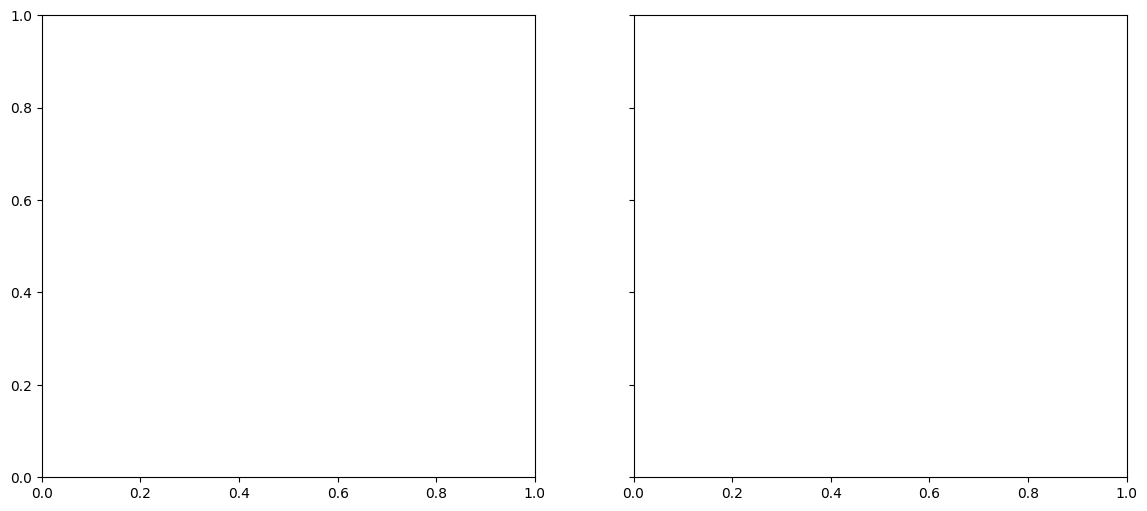

In [ ]:
# Wygeneruj i zinterpretuj learning curves dla dwóch modeli.
# Dataset: Digits
# Wymagania:
# Decision Tree (max_depth=None) - potencjalny overfitting
# Random Forest (n_estimators=50, max_depth=5) - zbalansowany
# Wykresy obok siebie z interpretacją

import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_digits
from sklearn.model_selection import (train_test_split,learning_curve)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Wczytanie danych
digits = load_digits()
X, y = digits.data, digits.target

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3,random_state=42, stratify=y)
print(f"Rozmiar zbioru treningowego: {X_train.shape[0]}")
print(f"Rozmiar zbioru testowego: {X_test.shape[0]}")

# Porównanie algorytmów
models = {
'Decision Tree': DecisionTreeClassifier(max_depth=None),
'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}
# Inicjalizacja wykresów obok siebie (1 wiersz, 2 kolumny)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for name, model in models.items():
# TEN SAM kod dla każdego modelu!
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
# Średnie wyniki i odchylenia standardowe (dla ładniejszego wykresu)
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    test_mean = test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)

    # Rysowanie linii i obszarów błędu
    ax.plot(train_sizes, train_mean, marker='o', color='blue', label='Training accuracy')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
    
    ax.plot(train_sizes, test_mean, marker='s', color='green', label='Validation accuracy')
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='green')

    # Konfiguracja pojedynczego wykresu
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Number of training samples')
    ax.set_ylabel('Accuracy')
    ax.legend(loc='lower right')
    ax.grid(True)

plt.tight_layout()
plt.show()